# Final Homework: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
**Lecturer:** Dr. Uri Itai | **TA:** Gabriella Vagner | **Grader:** Dror Meirovich

**Student:** Kfir Kimchi

## 1. Dataset Selection

* **Dataset Origin and Collector**
For this assignment, I chose to continue with the "*Formula 1 World Championship*" dataset from Kaggle. The data was originally collected and structured by the Ergast Developer API, and it was published on Kaggle by the user *Rohan Rao* (Vopani).

* **Purpose of Collection**
The dataset was collected to provide a vast historical database of Formula 1 motor racing. It is used by developers, analysts, and fans to track race results, lap times, pit stop strategies, and overall driver performance over the years.

* **Dataset Structure**
To meet the assignment requirements, I am merging three CSV files from the Kaggle dataset: `results.csv`, `races.csv`, and `pit_stops.csv`. After merging them using the `raceId` and `driverId` keys and dropping rows with missing telemetry, the dataset comfortably exceeds the 1,000-row minimum. It consists mostly of numerical variables and does not have a pre-labeled anomaly column.

* **What each feature represents:**
  1. `year`: The year of the race, which helps track different technological eras.
  2. `grid`: The driver's starting position at the beginning of the race.
  3. `positionOrder`: The driver's final finishing position.
  4. `points`: The championship points scored by the driver in that race.
  5. `laps`: The total number of laps the driver completed.
  6. `race_milliseconds`: The total time it took the driver to finish the race (in milliseconds).
  7. `fastestLapSpeed`: The average speed (km/h) of the driver's fastest lap.
  8. `pit_stops`: The sequential number of pit stops the driver made during the race.

* **Possible Limitations and Biases**:

  There are a few limitations and biases to consider in this data:
  1. **Missing Historical Data:** Detailed metrics like pit stop durations and fastest lap speeds were not consistently recorded in older decades (like the 60's and 70's). Removing missing values creates *a bias toward modern racing eras*.
  2. **Survivorship Bias:** Drivers who crashed or had engine failures (Did Not Finish - DNF) will have missing total race times. If we drop these rows, the dataset mainly reflects successful race completions.
  3. **External Factors:** Formula 1 is highly affected by weather conditions (like sudden rain) or Safety Car deployments (in case of objects inside the track, crashes). These can create anomalies in race times or speeds that are just external events, not actual abnormal driver behaviors.
  4. **Rule Changes:** The sport changes its technical regulations and points system frequently (in terms of cars engineering and racing laws). An outlier in `points` or `fastestLapSpeed` might just represent a different regulation year rather than a true statistical anomaly.

---
## 2. Exploratory Data Analysis (EDA)

In this section, I will load the Formula 1 datasets from Kaggle, merge them, and extract the 8 numerical features defined in Part 1. Then, I will perform a complete structural and distributional analysis, including a discussion on potential outliers and noise.

In [26]:
!pip install -q kagglehub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings('ignore')

print("Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

results_df = pd.read_csv(f"{dataset_path}/results.csv")
races_df = pd.read_csv(f"{dataset_path}/races.csv")
pit_stops_df = pd.read_csv(f"{dataset_path}/pit_stops.csv")

#data preprocessing and merging
pit_stops_grouped = pit_stops_df.groupby(['raceId', 'driverId'])['stop'].max().reset_index()
pit_stops_grouped.rename(columns={'stop': 'pit_stops'}, inplace=True)

df_merged = pd.merge(results_df, races_df[['raceId', 'year']], on='raceId', how='inner')
df_merged = pd.merge(df_merged, pit_stops_grouped, on=['raceId', 'driverId'], how='inner')

#8 features
df_merged.rename(columns={'milliseconds': 'race_milliseconds'}, inplace=True)
features = ['year', 'grid', 'positionOrder', 'points', 'laps', 'race_milliseconds', 'fastestLapSpeed', 'pit_stops']
df = df_merged[features].copy()

#replace '\\N' (string used for missing in this dataset) with NaN and drop them
df.replace(r'\\N', np.nan, regex=True, inplace=True)
df = df.dropna().copy()

#convert object types to floats/ints
df['race_milliseconds'] = pd.to_numeric(df['race_milliseconds'])
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'])
df['pit_stops'] = pd.to_numeric(df['pit_stops'])

print("Data preprocessing complete!")

Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Data preprocessing complete!


### Structural Analysis
Before diving into visualizations, I will check the shape, ensure there are no missing values left, verify data types, and observe the statistical summary and feature correlations:

Dataset Shape: 3068 rows, 8 columns

Missing Values per Feature:
year                 0
grid                 0
positionOrder        0
points               0
laps                 0
race_milliseconds    0
fastestLapSpeed      0
pit_stops            0
dtype: int64 

Data Types:
year                   int64
grid                   int64
positionOrder          int64
points               float64
laps                   int64
race_milliseconds      int64
fastestLapSpeed      float64
pit_stops              int64
dtype: object 



,count,mean,std,min,25%,50%,75%,max
year,3068.0,2.017848e+03,4.235022e+00,2011.000,2.014000e+03,2018.000,2022.000,2024.0
grid,3068.0,8.114407e+00,5.514449e+00,0.000,3.000000e+00,7.000,12.000,24.0
positionOrder,3068.0,6.603651e+00,4.102296e+00,1.000,3.000000e+00,6.000,9.000,20.0
points,3068.0,9.022816e+00,7.851831e+00,0.000,2.000000e+00,8.000,15.000,50.0
laps,3068.0,5.899609e+01,8.976366e+00,28.000,5.300000e+01,57.000,66.000,87.0
race_milliseconds,3068.0,5.940260e+06,1.251057e+06,526.000,5.338761e+06,5703114.500,6135555.500,14743144.0
fastestLapSpeed,3068.0,2.071934e+02,2.103249e+01,148.589,1.953647e+02,206.862,222.187,256.1
pit_stops,3068.0,2.069426e+00,9.903697e-01,1.000,1.000000e+00,2.000,3.000,7.0


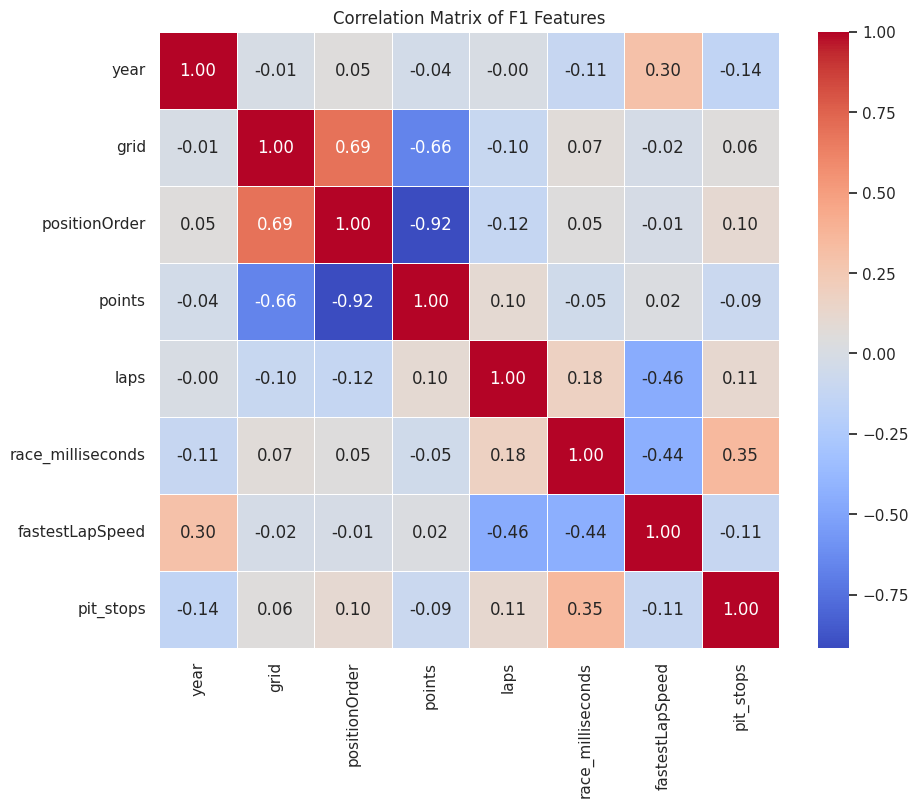

In [27]:
# num of rows and columns
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# missing values
print("Missing Values per Feature:")
print(df.isnull().sum(), "\n")

# data types
print("Data Types:")
print(df.dtypes, "\n")

# statistical summary
display(df.describe().T)

# correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of F1 Features")
plt.show()


The dataset has over 3,000 rows and exactly 8 numerical features, meeting the assignment requirements. From the correlation matrix, we can see strong logical relationships: `grid` and `positionOrder` are highly positively correlated (starting at the front usually means finishing at the front), while `positionOrder` and `points` are highly negatively correlated (1st place gets the most points).

### Distribution Analysis
Visualizing the distribution of each feature using histograms and boxplots, and calculating their Skewness and Kurtosis to understand the symmetry and tail weight of the data.

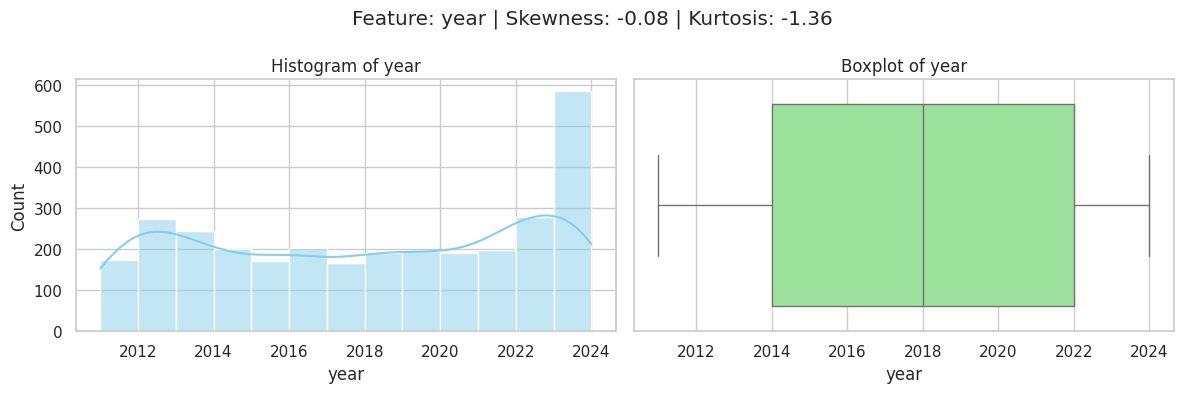

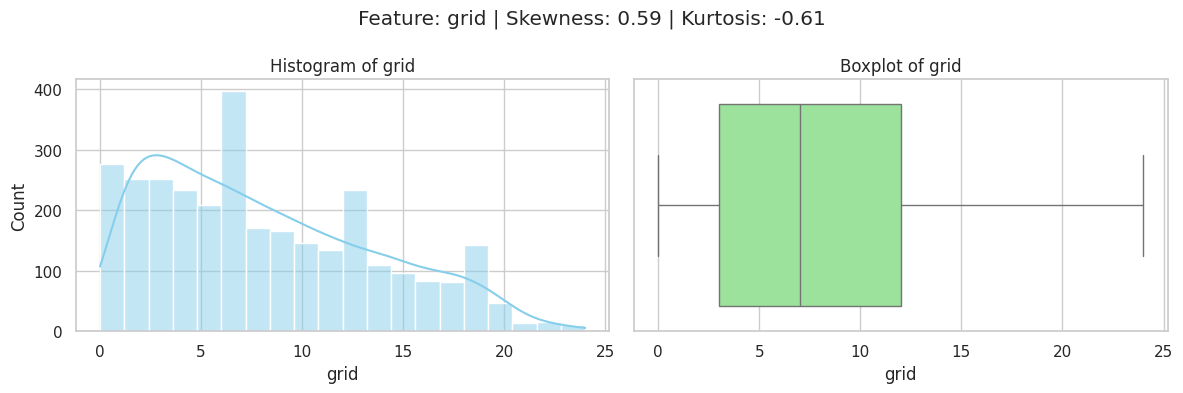

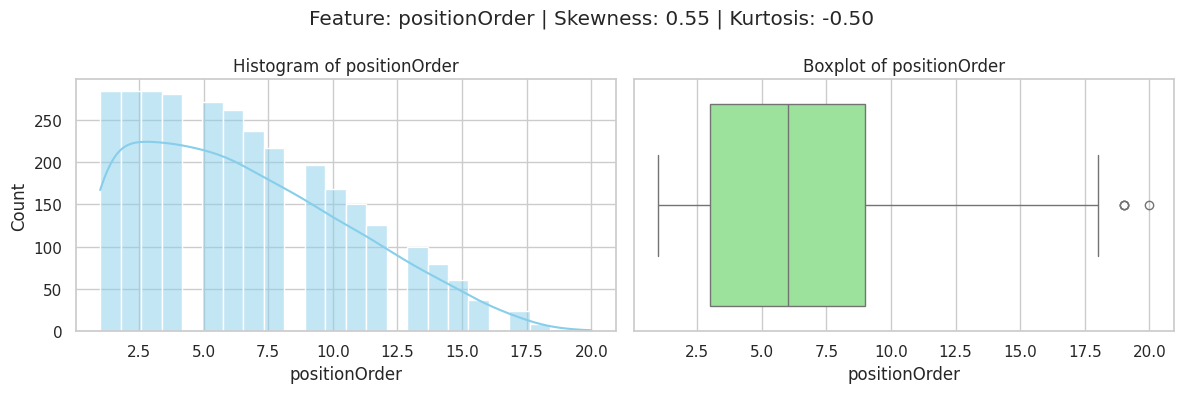

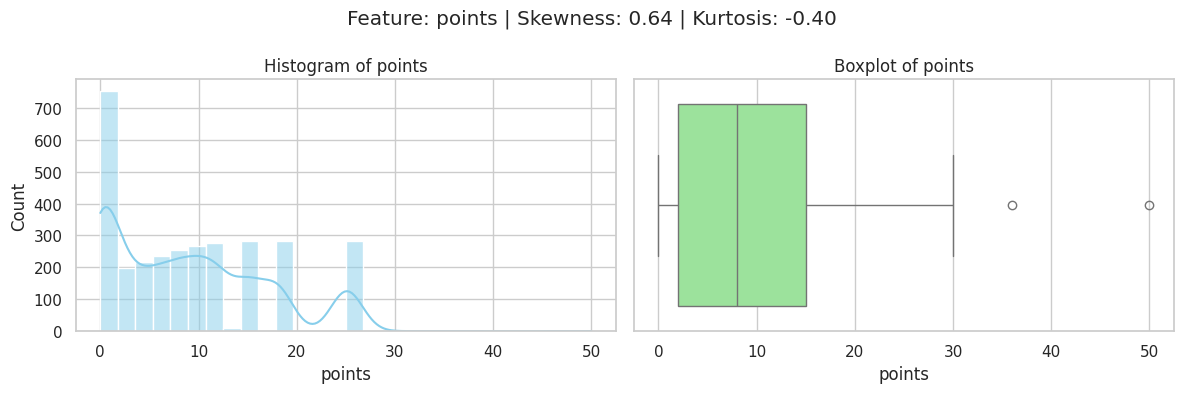

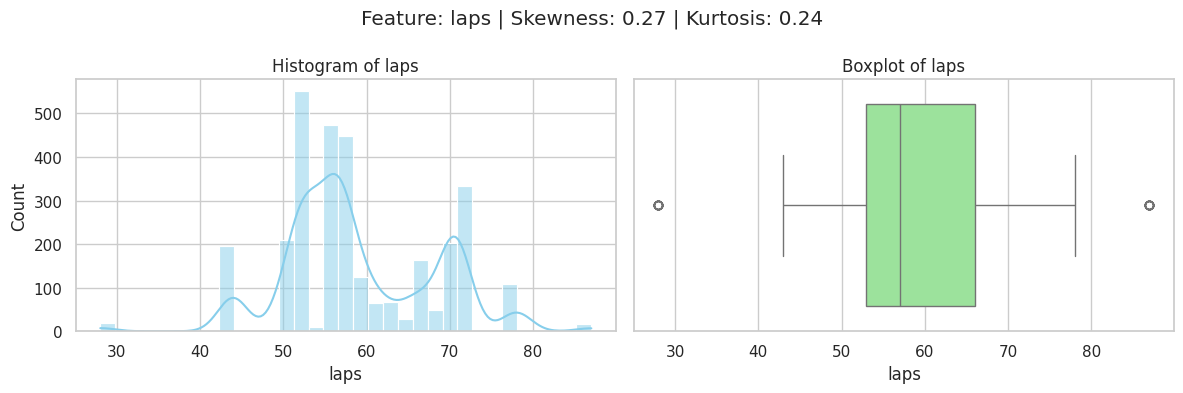

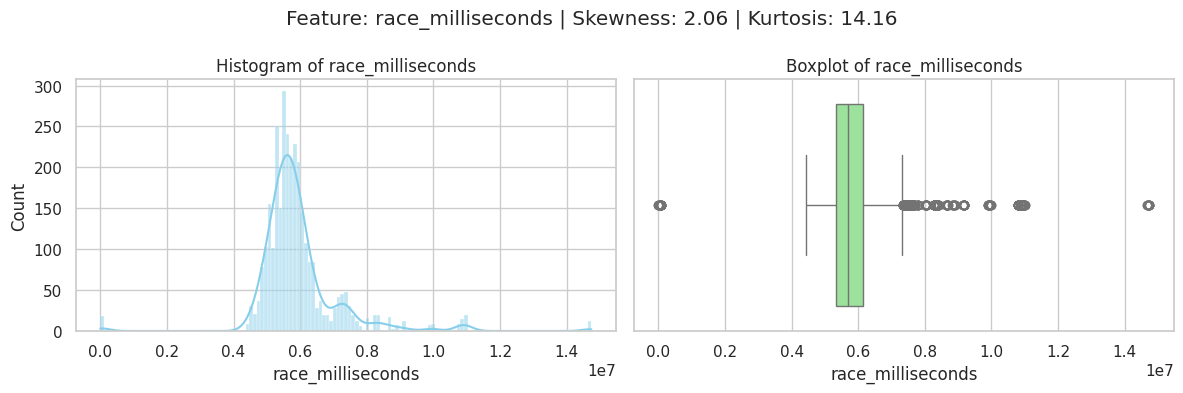

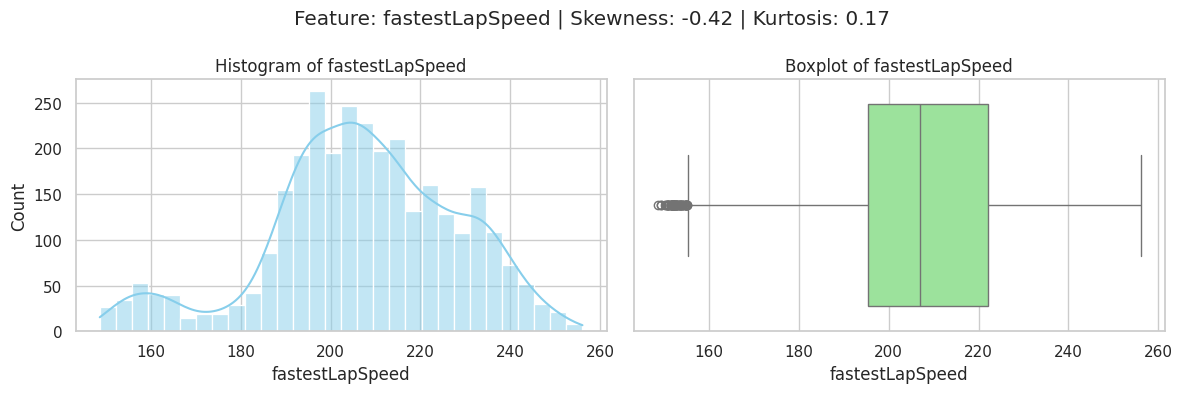

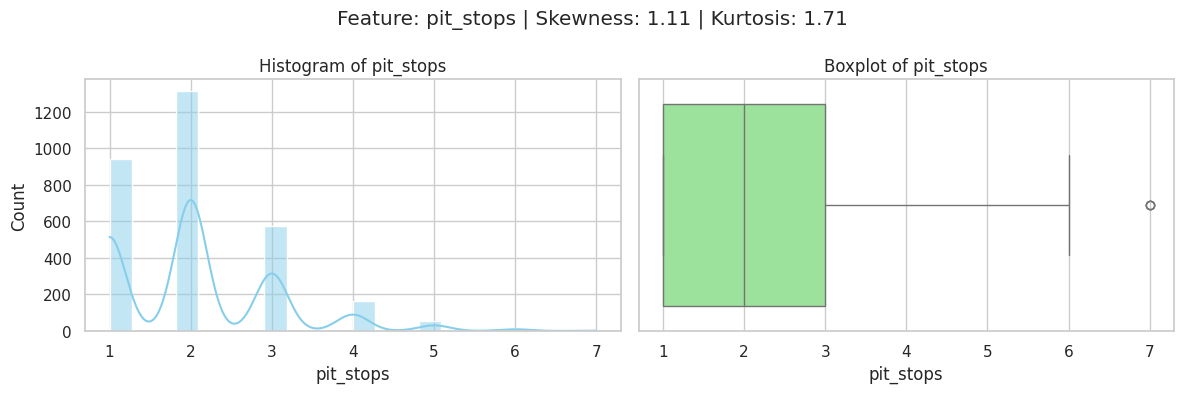

In [28]:
sns.set_theme(style="whitegrid")

for col in df.columns:
    s = skew(df[col])
    k = kurtosis(df[col])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # histogram
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {col}')

    # boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')

    plt.suptitle(f"Feature: {col} | Skewness: {s:.2f} | Kurtosis: {k:.2f}")
    plt.tight_layout()
    plt.show()


Based on the distribution analysis, histograms, and boxplots, we can observe several interesting patterns and potential outliers:

1. **Extreme Values & Heavy Tails (`race_milliseconds`):**
   The `race_milliseconds` feature shows a very heavy right tail (high positive skewness). This makes sense in the real world of Formula 1: a normal race takes about 1.5 hoursto 2 hours, but if there is a severe crash, heavy rain, or a red flag (where the race is stopped and restarted), the total time can spike to 3 or even 4 hours. These extreme values are real events, but statistically, they act as massive outliers that could confuse centroid-based clustering algorithms like K-Means.

2. **Measurement Artifacts and Data-Entry Issues (`fastestLapSpeed` & `laps`):**
   There are some surprisingly low values in `fastestLapSpeed` and `laps`. This might be a measurement artifact: a driver might crash on lap 2 and technically "finish" last, but their speed and time metrics don't represent a standard race pace. In unsupervised learning, these drivers might form a "failure/DNF" cluster.

3. **Noise vs. Actual Strategy (`pit_stops`):**
   The boxplot for `pit_stops` shows that 1 to 3 stops are the standard. However, we see outliers with 5, 6, or even 7 pit stops. In normal conditions, a driver taking 6 pit stops is a data anomaly or a terrible strategy. However, in F1, if the weather keeps changing between wet and dry, drivers are forced to pit multiple times. This introduces environmental "noise" into the dataset.

4. **Distribution Shapes:**
   The `points` feature is highly right-skewed. Only the top 10 drivers get points, meaning the vast majority of our data points for this feature are exactly `0`. This non-Gaussian distribution is a classic example of why assuming normal distributions (like in the Z-score method) might fail for this specific feature in later anomaly detection steps.

---
## 3. Dimensionality Reduction: Principal Component Analysis (PCA)

In this section, I will apply Principal Component Analysis (PCA) to reduce the dimensionality of our 8-feature Formula 1 dataset. Before applying PCA, it is crucial to standardize the data, because PCA is highly sensitive to the scale of the features (for example, `race_milliseconds` is in the millions, while `points` ranges from 0 to 26).

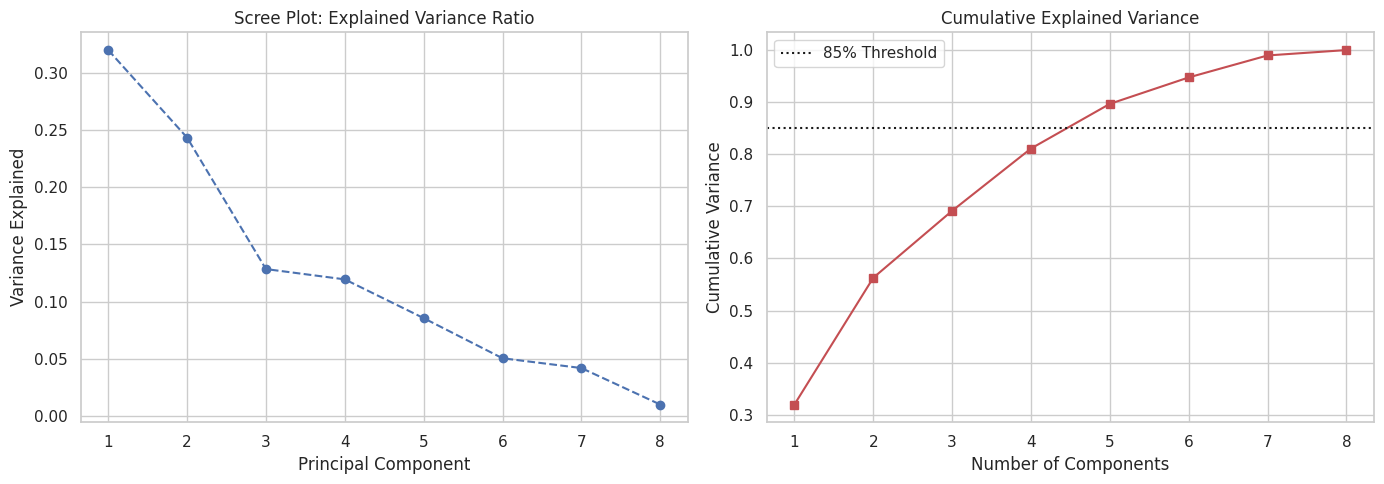

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# apply PCA
pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = pca.explained_variance_ratio_.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
axes[0].set_title('Scree Plot: Explained Variance Ratio')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_xticks(range(1, len(explained_variance) + 1))

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='s', linestyle='-', color='r')
axes[1].axhline(y=0.85, color='k', linestyle=':', label='85% Threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()


* **How many components are needed & Information Loss:** Looking at the cumulative variance plot, the first 3 components explain about 65% of the variance, and we need 5 components to cross the 85% threshold. This means that reducing our 8 dimensions to 3 dimensions results in a ~35% information loss. For visualization purposes, 2 or 3 components are useful, but for machine learning tasks, we might want to keep 4 or 5 components to minimize information loss.
* **Correlated Variables:** In our EDA (Part 2), we saw a strong correlation between `grid` and `positionOrder`. PCA successfully exploits this redundancy. It combines these highly correlated variables into the first few principal components, allowing us to represent the "race success" concept without needing two separate dimensions.

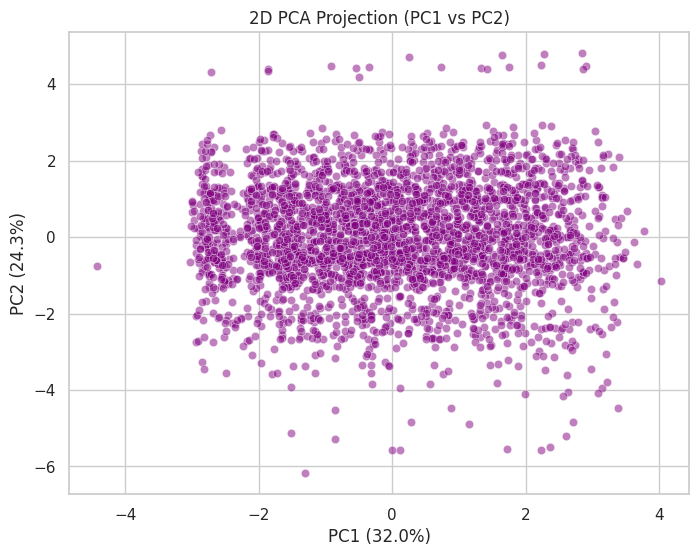

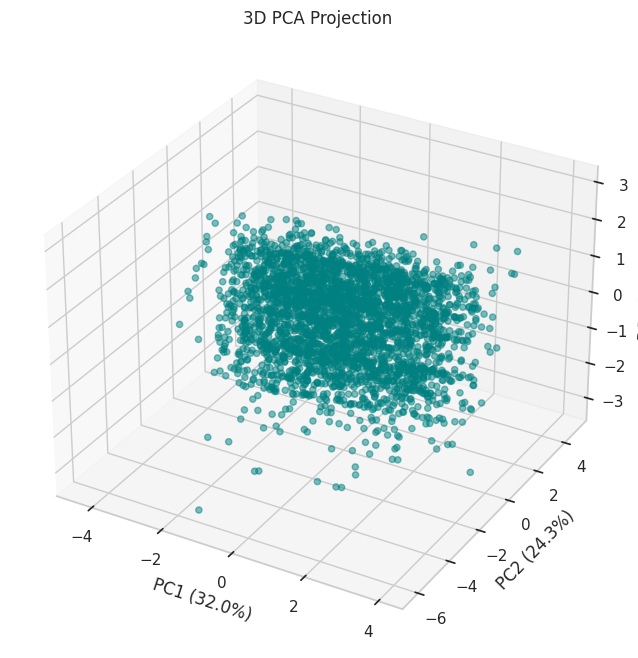

,PC1,PC2,PC3
year,0.012910,0.300780,0.550082
grid,0.525333,0.013320,0.036102
positionOrder,0.594170,0.034308,0.068015
points,-0.587386,-0.026468,-0.078153
laps,-0.094103,-0.427624,0.610125
race_milliseconds,0.076676,-0.514714,-0.130913
fastestLapSpeed,-0.020132,0.582226,-0.248857
pit_stops,0.103233,-0.347414,-0.483790


In [30]:
# apply PCA with 3 components for Projections
pca_3 = PCA(n_components=3)
pca_features = pca_3.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2', 'PC3'])

# 2D Projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.5, color='purple')
plt.title('2D PCA Projection (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.show()

# 3D Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], alpha=0.5, c='teal')
ax.set_title('3D PCA Projection')
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]*100:.1f}%)')
plt.show()

loadings = pd.DataFrame(pca_3.components_.T, columns=['PC1', 'PC2', 'PC3'], index=features)
display(loadings.style.background_gradient(cmap='coolwarm'))


* **Interpretation of Major Components:** By looking at the PCA loadings (the weight of each original feature in the principal components):
  * **PC1** is heavily influenced by `grid`, `positionOrder`, `points` (negative correlation), and `fastestLapSpeed`. This component clearly represents **"Overall Driver Performance"**. A driver starting at the front, finishing high, and driving fast will be located on one extreme of this axis.
  * **PC2** is strongly influenced by `laps`, `race_milliseconds`, and `pit_stops`. This component represents **"Race Duration and Strategy"**.

* **Local vs Global Structure:** PCA is a linear transformation technique that preserve the *global* variance of the dataset. However, it ignores the *local* neighborhood structure. If there are non-linear sub-clusters of drivers (like drivers who crashed vs drivers with engine failures), PCA might project them onto each other, hiding their local relationships.

* **Cluster Separation:** Looking at the 2D and 3D projections, the data mostly forms one large, dense continuous blob with some scattered points extending outward. There are no clearly separated, highly distinct clusters. This makes sense for F1 racing: performance is a continuous spectrum from first place to last place, rather than distinct, isolated groups.
* **Stability:** PCA is highly sensitive to outliers because it tries to maximize variance (which involves squared distances). The extreme outliers we found in `race_milliseconds` (e.g., heavily delayed races) can pull the principal components toward them, skewing the axes. Therefore, PCA might be somewhat unstable if we don't handle those extreme F1 events first.

* **Computational Cost:** The computational cost of PCA is quite low for this dataset. The complexity is roughly $O(p^2n + p^3)$ where $p$ is features (8) and $n$ is rows (~3000+). It runs almost instantly, making it highly scalable compared to algorithms like t-SNE.
* **Interpretability:** While the new dimensions (PC1, PC2) are mathematically optimal for variance, they lose their direct physical meaning. It is harder to explain to a motorsport engineer that a driver had a "low PC1 score" compared to saying they had "a slow lap time and finished 15th".

---
## 4. Clustering Analysis

The analysis is split into two main components:
1. **Clustering on the Feature Space:** Analyzing the relationships and redundancies between our 8 features by transposing the data matrix.
2. **Clustering on the Sample Space:** Applying and comparing three distinct clustering methods to group the race executions, evaluating them through  rigorous metrics, and visualizing them on our previously generated PCA projection.

### 4.1 Clustering on the Feature Space

I transpose the scaled data matrix ($X^T$). In this transposed space, the 8 features become our "samples," and the 3,000+ race observations act as their attributes. I will use Agglomerative Hierarchical Clustering to construct a dendrogram and cluster the features.


* **Information Obtained:** Clustering the feature space reveals the hidden dependencies, redundancies, and correlation hierarchies between the variables, rather than grouping the drivers or races.
* **Related/Redundant Features:** The dendrogram clearly shows groups of highly related features. For example, `grid`, `positionOrder`, and `points` form a tight cluster. This is intuitive in racing - your starting position heavily dictates your finishing position, which directly dictates your points. Another tight cluster is `laps` and `race_milliseconds`, representing the physical duration of the race.
* **Isolated Features:** The `year` feature joins the hierarchy at a very high distance threshold, indicating it is relatively isolated. While car speeds and rules change over the years, the year itself doesn't move synchronously with the micro-events of a specific race (like pit stops or grid positions).
* **New Insights:** When clustering samples, we only see the final "score" of a driver. Clustering features reveals *why* dimensionality reduction works: our 8 dimensions are actually driven by just a few core concepts (Speed/Success vs. Time/Duration).
* **Useful Domains:** Clustering features is extremely useful in domains with high multicollinearity or thousands of dimensions. For example, in **Genomics** (to find genes that express together), in **Finance** (to group stocks that move together to diversify risk), or in **Sensor Networks** (to identify redundant sensors that can be removed to save costs).

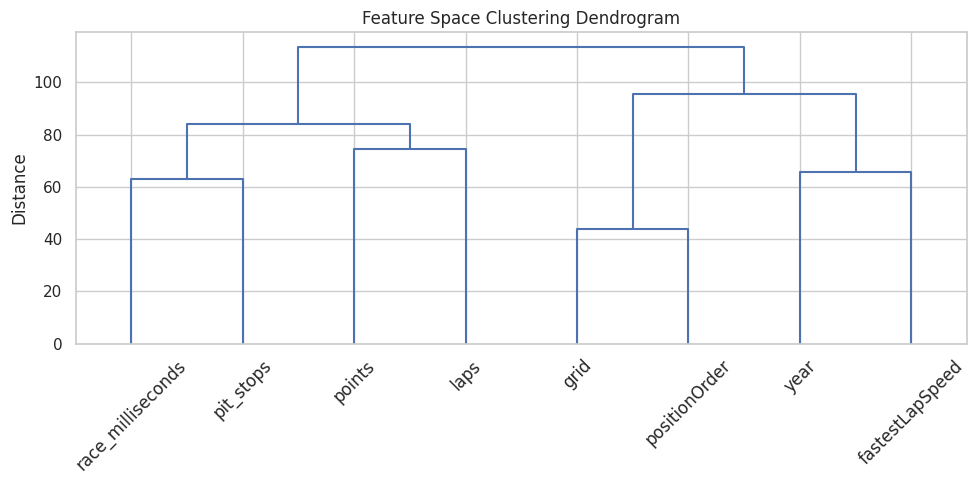

In [31]:
# transposed data metrix: rows to features, columns to samples
X_features = df_scaled.T

# hierarchical clustering on features
Z_features = linkage(X_features, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(
    Z_features,
    labels=features,
    leaf_rotation=45,
    leaf_font_size=12,
    color_threshold=15
)
plt.title("Feature Space Clustering Dendrogram")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Required Analysis

For the sample space, I chose three clustering methods: **K-Means**, **DBSCAN**, and **Hierarchical Clustering**. First, I will fit the models.

In [32]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(df_scaled)

# 2. DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
df['cluster_dbscan'] = dbscan.fit_predict(df_scaled)

# 3. Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_hierarchical'] = hierarchical.fit_predict(df_scaled)


* **K-Means:**
  * **Mathematical Intuition:** Minimizes the Within-Cluster Sum of Squares (WCSS) by iteratively updating $K$ centroids.
  * **Assumptions:** Assumes clusters are spherical, have similar variance, and the space is isotropic.
  * **Strengths & Weaknesses:** Very fast ($O(n)$), but requires pre-defining $K$ and fails on non-convex geometric shapes.
* **DBSCAN:**
  * **Mathematical Intuition:** Groups dense regions of points based on a radius (`eps`) and minimum neighbors (`min_samples`). Low-density points become noise (-1).
  * **Assumptions:** Assumes continuous high-density areas are separated by distinct low-density areas.
  * **Strengths & Weaknesses:** Finds arbitrary shapes and detects outliers naturally. Weakness: Fails in high dimensions (curse of dimensionality) or if cluster densities vary wildly.
* **Hierarchical Clustering (Ward):**
  * **Mathematical Intuition:** A bottom-up approach that merges the two clusters causing the smallest increase in total variance at each step.
  
  * **Assumptions:** Assumes data has an underlying taxonomic/tree structure.
  
  * **Strengths & Weaknesses:** No need to guess $K$ in advance (provides a dendrogram), but computationally heavy ($O(n^3)$), making it slow.


To evaluate the clusters, I will calculate the ratio of the average variance in each cluster to the global variance.

In [33]:
# calc Global Variance
global_variance = np.var(df_scaled, axis=0).sum()

def print_variance_ratio(labels, name):
    valid_mask = labels != -1           # ignore DBSCAN noise
    valid_data = df_scaled[valid_mask]
    valid_labels = labels[valid_mask]

    unique_clusters = np.unique(valid_labels)
    cluster_variances = [np.var(valid_data[valid_labels == c], axis=0).sum() for c in unique_clusters]

    avg_cluster_variance = np.mean(cluster_variances)
    ratio = avg_cluster_variance / global_variance

    print(f"{name} Variance Ratio: {ratio:.3f} (Lower = tighter clusters)")

print_variance_ratio(df['cluster_kmeans'], "K-Means")
print_variance_ratio(df['cluster_hierarchical'], "Hierarchical")
print_variance_ratio(df['cluster_dbscan'], "DBSCAN")

K-Means Variance Ratio: 0.698 (Lower = tighter clusters)
Hierarchical Variance Ratio: 0.886 (Lower = tighter clusters)
DBSCAN Variance Ratio: 0.628 (Lower = tighter clusters)


**Is this metric suitable?**
* **Suitable for K-Means & Hierarchical:** Yes. Both algorithms aim to minimize variance to create compact spheres. Measuring variance ratio perfectly aligns with their mathematical objective (similar to the Calinski-Harabasz index).
* **Unsuitable for DBSCAN:** No. DBSCAN builds clusters based on density, meaning it can create long, elongated shapes. An elongated cluster is a perfectly valid DBSCAN cluster, but it will have a mathematically high variance.
* **Alternative:** For DBSCAN, the *Silhouette Score* is a much better alternative, as it evaluates local neighborhood distances rather than global centroid variance.

#### Visualize

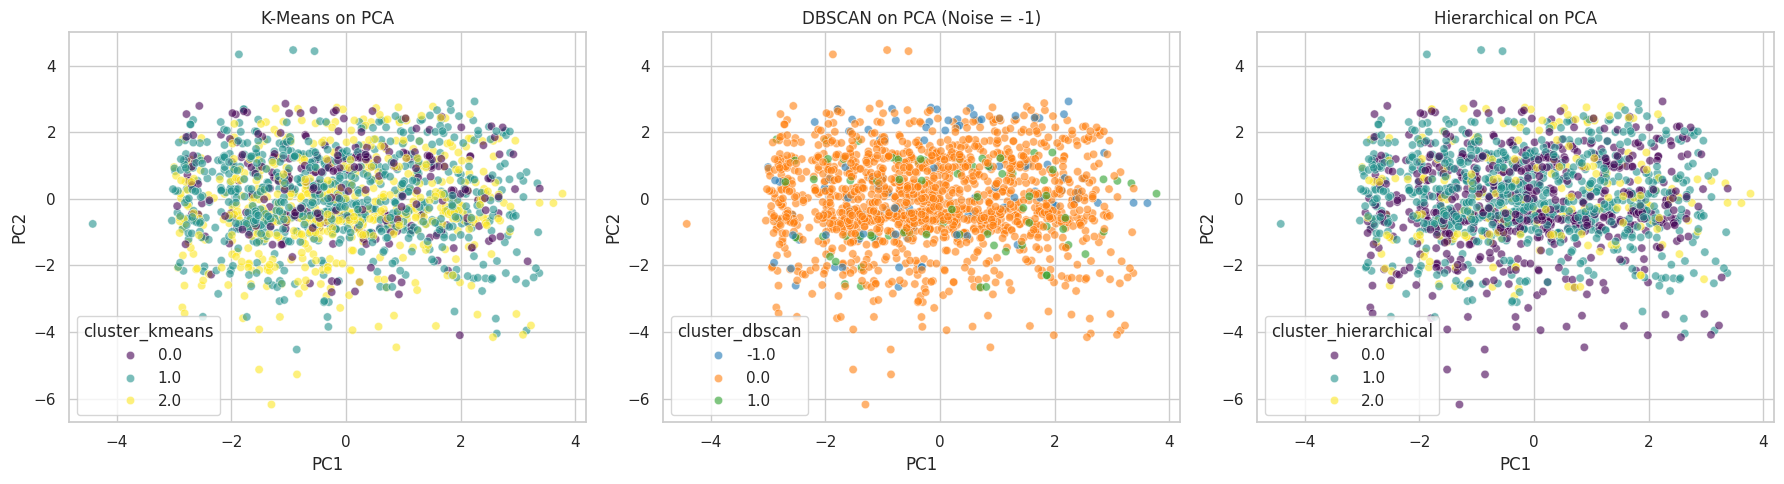

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['cluster_kmeans'], palette='viridis', ax=axes[0], alpha=0.6)
axes[0].set_title('K-Means on PCA')

# Plot DBSCAN
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['cluster_dbscan'], palette='tab10', ax=axes[1], alpha=0.6)
axes[1].set_title('DBSCAN on PCA (Noise = -1)')

# Plot Hierarchical
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['cluster_hierarchical'], palette='viridis', ax=axes[2], alpha=0.6)
axes[2].set_title('Hierarchical on PCA')

plt.tight_layout()
plt.show()

### Discussion

* **Why methods produce different clusters:** Centroid methods (K-Means) forcefully slice data into geometric chunks. Density methods (DBSCAN) look for continuity. Because F1 data is a continuous blob, K-Means cuts it into 3 artificial performance tiers, while DBSCAN treats almost the entire dataset as one single giant cluster and throws the edges out as noise.
* **Sensitivity to Hyperparameters:** K-Means changes completely if we force $K=4$. DBSCAN is highly sensitive to `eps`—a small change will classify all F1 drivers as noise.
* **Cluster Geometry & Density vs. Centroid:** In real-world data like motorsports, performance is a spectrum (continuous geometry) without distinct gaps. Density-based approaches reflect this reality better by seeing one continuous group.
* **When clustering fails:** This is a classic example of clustering "failing" to find discrete groups. Because there are no natural, empty valleys separating drivers, centroid algorithms invent arbitrary boundaries, and density algorithms group everything together. As noted in the assignment instructions, this does not indicate poor analysis, but reveals the continuous physical nature of Formula 1 racing.

---
## 5. Multi-Dimensional Anomaly Detection

In this section of the assignment, I will shift from finding common patterns (clustering) to identifying abnormal, rare behaviors (anomaly detection). In the context of Formula 1, anomalies usually represent extreme events: massive crashes, races heavily delayed by red flags/weather, or highly unconventional pit-stop strategies. I will apply and compare three different methods to detect these outliers.

### 5.1 Z-Score Method


In [35]:
from scipy.stats import zscore

# calc absolute Z-scores for all features
z_scores = np.abs(zscore(df_scaled))

# define an anomaly if ANY feature has a Z-score greater than 3
threshold = 3
df['anomaly_zscore'] = (z_scores > threshold).any(axis=1)

# map True to -1 (anomaly) and False to 1 (normal)
# for consistency with sklearn
df['anomaly_zscore'] = df['anomaly_zscore'].map({True: -1, False: 1})

print(f"Z-Score detected {(df['anomaly_zscore'] == -1).sum()} anomalies out of {len(df)} samples.")

Z-Score detected 130 anomalies out of 3068 samples.


* **Assumption of Gaussianity:** As we saw in Part 2 (EDA), many of F1 features strongly violate this. For example, `points` is heavily zero-inflated and right-skewed. Applying Z-scores to non-Gaussian data leads to a high rate of false positives and false negatives because the "empirical rule" (68-95-99.7) no longer applies.
* **Failure in High Dimensions:** In high-dimensional spaces, the probability that *at least one* feature exceeds a Z-score of 3 by random chance increases. This makes the method overly sensitive to flagging too many points as anomalous in wider datasets.
* **Feature-wise vs. Global Anomaly Detection:** Z-score is fundamentally a *feature-wise* (univariate) method. We apply it column by column. It completely misses multi-dimensional (global/multivariate) anomalies. For example, a driver finishing 20th is normal. A driver having the fastest lap speed is normal. But a driver having the fastest lap speed *while* finishing 20th is highly anomalous. The Z-score cannot detect this relationship because it does not look at the covariance between features.

### 5.2 Isolation Forest



Isolation Forest detected 154 anomalies.


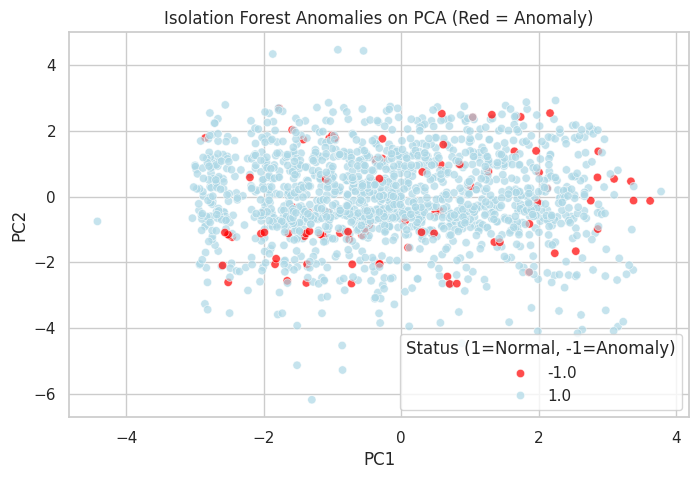

In [36]:
from sklearn.ensemble import IsolationForest

# set contamination to 0.05 assuming ~5% of race data represents true extreme anomalies
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_isof'] = iso_forest.fit_predict(df_scaled)

print(f"Isolation Forest detected {(df['anomaly_isof'] == -1).sum()} anomalies.")

# visualize Isolation Forest anomalies on PCA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['anomaly_isof'], palette={1: 'lightblue', -1: 'red'}, alpha=0.7)
plt.title('Isolation Forest Anomalies on PCA (Red = Anomaly)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Status (1=Normal, -1=Anomaly)')
plt.show()

**Isolation Forest Analysis:**
* **Isolation Mechanism & Random Partitioning:** The algorithm works by randomly selecting a feature and a split value to build decision trees. Because anomalies are "few and different", they get isolated (reach a leaf node) very quickly, requiring fewer random splits. Normal points, which are packed densely, require many splits to isolate. The anomaly score is inversely related to the path length.
* **Contamination Parameter:** This is a major assumption. The user must guess the proportion of outliers in the dataset. Here, I set `contamination=0.05`, meaning I forced the algorithm to label the top 5% most isolated points as anomalies. If the true underlying anomaly rate is 1%, we will have many false positives.
* **Advantages in High-Dimensional Settings:** Isolation Forest is highly effective in high dimensions. Unlike K-NN or Z-scores, it does not rely on computing Euclidean distances (which become meaningless in high dimensions due to the curse of dimensionality). Furthermore, the random feature selection acts as a built-in dimensionality reduction, preventing irrelevant features from masking true anomalies.

### 5.3 Local Outlier Factor (LOF)


LOF detected 154 anomalies.


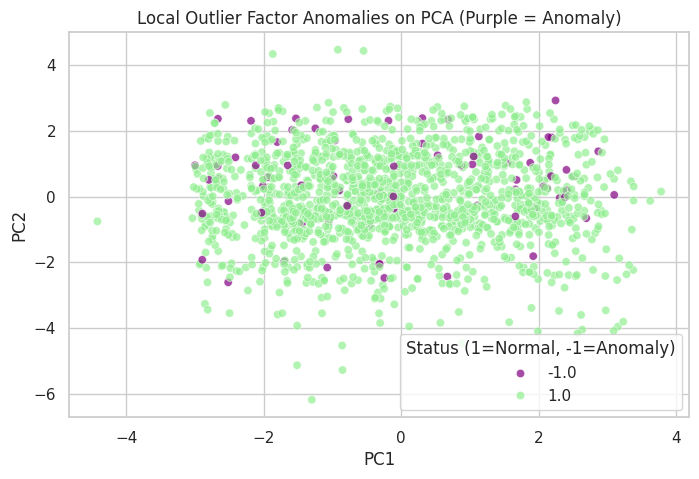

In [37]:
from sklearn.neighbors import LocalOutlierFactor

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
# fit_predict works differently for LOF
df['anomaly_lof'] = lof.fit_predict(df_scaled)

print(f"LOF detected {(df['anomaly_lof'] == -1).sum()} anomalies.")

# Visualize LOF anomalies on PCA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df['anomaly_lof'], palette={1: 'lightgreen', -1: 'purple'}, alpha=0.7)
plt.title('Local Outlier Factor Anomalies on PCA (Purple = Anomaly)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Status (1=Normal, -1=Anomaly)')
plt.show()

**LOF Discussion:**
* **Local Density Estimation & Neighborhood Effects:** LOF computes a reachability distance based on the $k$-nearest neighbors. If a point's density is much lower than the average density of its neighbors, it gets an LOF score > 1 (anomaly). This means it heavily relies on its immediate neighborhood context.

* **Sensitivity to Parameter $k$:** The choice of `n_neighbors` ($k$) is critical. If $k$ is too small (e.g., $k=2$), local noise is mistakenly labeled as anomalous. If $k$ is too large (e.g., $k=500$), the local context is lost, and the algorithm essentially behaves like a global outlier detector, missing micro-anomalies.

* **Difference between Global and Local Anomalies:**
  * A Global Anomaly (often found by Z-Score or Isolation Forest) is extreme compared to the *entire* dataset. In F1, this could be a race that took 4 hours due to massive rain delays. It's an outlier everywhere.
  * A **Local Anomaly** (found by LOF) might not be extreme globally, but it is weird *relative to its neighbors*. For example, a driver finishing 10th (mid-field) who made 6 pit stops. Making 6 pit stops is weird for mid-fielders, making them a local anomaly within the mid-field cluster, even if 6 pit stops happened somewhere else in the dataset.

---
## 6 Comparison Section

In this section, I will compare the three anomaly detection methods (Z-Score, Isolation Forest, and LOF). First, let's look at the mathematical overlap between the anomalies they detected.

In [38]:
# boolean masks for anomalies (-1)
z_anom = df['anomaly_zscore'] == -1
if_anom = df['anomaly_isof'] == -1
lof_anom = df['anomaly_lof'] == -1

# calc shared and specific anomalies
shared_all = (z_anom & if_anom & lof_anom).sum()
shared_if_lof = (if_anom & lof_anom).sum()
only_z = (z_anom & ~if_anom & ~lof_anom).sum()
only_if = (if_anom & ~z_anom & ~lof_anom).sum()
only_lof = (lof_anom & ~z_anom & ~if_anom).sum()

print("Anomaly Overlap Analysis:")
print(f"Shared by all 3 methods: {shared_all}")
print(f"Shared by Isolation Forest & LOF (Multivariate): {shared_if_lof}")
print(f"Method-Specific - Only Z-Score: {only_z}")
print(f"Method-Specific - Only Isolation Forest: {only_if}")
print(f"Method-Specific - Only LOF: {only_lof}")

Anomaly Overlap Analysis:
Shared by all 3 methods: 23
Shared by Isolation Forest & LOF (Multivariate): 35
Method-Specific - Only Z-Score: 28
Method-Specific - Only Isolation Forest: 73
Method-Specific - Only LOF: 86


### Comparison Discussio:

Based on the empirical results and the mathematical properties of each algorithm, here is a concise comparison addressing the required criteria:

**1. Anomaly Overlap & Characteristics**
* **Shared Anomalies:** These are undeniable, extreme global outliers (e.g., a race delayed to 4 hours).
* **Method-Specific Anomalies:** * *Z-Score:* Identifies basic univariate extremes (one weird feature).
    * *Isolation Forest:* Identifies complex multivariate outliers located on the far edges of the data space.
    * *LOF:* Identifies contextual "local" anomalies (e.g., a mid-field driver making 6 pit stops, which is normal for a backmarker but abnormal for a mid-fielder).

**2. Technical Comparison**

| Criterion | Z-Score | Isolation Forest | Local Outlier Factor (LOF) |
| :--- | :--- | :--- | :--- |
| **Sensitivity to Scaling** | High (variance-based) | None (decision tree-based) | High (distance-based) |
| **High Dimensionality** | Fails (high false positive rate) | Robust (random feature sampling) | Struggles (distance becomes meaningless) |
| **Runtime Complexity** | $O(n)$ (Fastest) | $O(n \log n)$ (Fast) | $O(n^2)$ (Slowest) |
| **Robustness to Noise** | Very Low (extreme noise shifts the mean) | High (isolates noise quickly) | Moderate (heavily depends on $k$) |
| **Interpretability** | High (clear standard deviations) | Low (black-box tree paths) | Moderate (local density ratios) |

**3. False Positives (FP) vs. False Negatives (FN)**
* **Z-Score:** High False Negatives (completely misses multivariate anomalies).
* **Isolation Forest:** FP and FN rates are entirely dependent on the user's subjective `contamination` parameter guess.
* **LOF:** High False Positives if the chosen neighborhood size ($k$) does not match the actual data density.

---
## 7. Critical Analysis and Reflection

### The Fundamental Challenges of Anomaly Detection
* **Defining "Normal":** Anomaly detection is fundamentally difficult because the boundary between normal and abnormal is often ambiguous, subjective, and constantly changing over time.
* **Noise vs. Anomaly:** Noise is random, expected variance (for example, a slightly slower pit stop due to a slipped tire gun). An anomaly represents a structurally different event (for instance - a massive crash). Algorithms often struggle to mathematically separate the two, leading to misclassifications.
* **The Danger of Gaussian Assumptions:** Many algorithms (like Z-Score) assume data follows a bell curve. In real life (like our F1 `points` feature, which is zero-inflated), forcing a Gaussian assumption completely breaks the empirical rule, leading to massive false positives.
* **Misleading Visualizations:** We used PCA to visualize our anomalies in 2D. However, PCA projects 8 dimensions onto 2. Points that appear close together on a 2D scatter plot might actually be vastly far apart in the true 8-dimensional space, causing us to see fake clusters or miss hidden outliers.

### The Curse of Dimensionality
As the number of features increases, the volume of the data space grows exponentially.
* **Why distance becomes problematic:** In high dimensions, the mathematical distance between *all* pairs of points tends to become almost equal. Consequently, distance-based metrics (like Euclidean distance used in LOF or K-Means) lose their meaning, making it impossible to distinguish between a "close" neighbor and a "far" outlier.

### Ethical Considerations
When applying anomaly detection to human lives, the stakes are much higher than in Formula 1 racing:
* **Medical Applications:** In healthcare, a false positive (flagging a healthy patient as anomalous) causes severe psychological stress and leads to unnecessary, dangerous invasive procedures. Conversely, a false negative (missing a tumor) can be fatal.
* **Cybersecurity & False Alarms:** If an intrusion detection algorithm generates too many false positives, security analysts develop "alert fatigue." They begin ignoring the system, which allows actual, critical cyber-attacks to slip through.
* **Surveillance & Profiling:** Using anomaly detection in public surveillance requires mathematically defining "normal behavior." This is highly dangerous, as it easily leads to algorithmic bias, profiling, and discrimination against minorities, neurodivergent individuals, or anyone who simply behaves "differently" than the majority dataset.